# 13.1.1 序参量与有限随机重复

## 学习目标与先修知识

定义有符号和绝对序参量（order parameter），按规模和重复汇总结果。

先修：12.3 有限种群抽样、4.3 固定点（fixed point）与分岔（bifurcation）、5.2 方差（variance）。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

群体里每个个体只有 +1 或 −1 两种状态（state）。同样的相互作用强度，在 50 个和 800 个个体中会显得一样“有序”吗？一次向上跳动究竟说明什么？

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

四个个体当前两正两负，磁化为零。若下一步各自以一半概率（probability）选择 +1，给定一组抽样数后可先手算结果。

In [2]:
old=[1,-1,1,-1]; draws=[.2,.4,.6,.8]
new=[1 if u<.5 else -1 for u in draws]
print('旧磁化',sum(old)/4,'；新磁化',sum(new)/4,'；新状态',new)

旧磁化 0.0 ；新磁化 0.0 ；新状态 [1, 1, -1, -1]


## 模型假设

这是同步二值选择的教学模型（model）：每轮先读旧磁化 m，再让 N 个个体条件独立（conditional independence）地以概率 r=(1+tanh(βm))/2 取 +1。β 为无量纲（dimensionless）作用强度；固定规模、初态、暂态（transient）、总时长和随机数生成器。

## 数学解释与推导

磁化 $m=N^{-1}\sum_i s_i\in[-1,1]$ 是有符号序参量。给定旧状态，$E(m_{t+1}\mid m_t)=2r-1=\tanh(\beta m_t)$，
$\operatorname{Var}(m_{t+1}\mid m_t)=[1-\tanh^2(\beta m_t)]/N$。因此有限 $N$ 不会沿着条件期望（expectation）映射精确运行。符号对称的重复可能使 $E(m)$ 抵消；本节另报告尾窗平均 $|m|$，并把每次重复的摘要分开保存。$1/\sqrt N$ 的条件标准差（standard deviation）仅是一步抽样尺度，不是已经证明的临界指数（critical exponent）。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def meanfield_step(spins, beta, draws):
    """Synchronous binary-choice update with supplied U[0,1) draws."""
    n = len(spins)
    magnetization = sum(spins) / n
    probability_plus = (1 + math.tanh(beta * magnetization)) / 2
    return [1 if draw < probability_plus else -1 for draw in draws]


def meanfield_path(initial, beta, draws_by_step):
    current = list(initial)
    magnetizations = [sum(current) / len(current)]
    for draws in draws_by_step:
        current = meanfield_step(current, beta, draws)
        magnetizations.append(sum(current) / len(current))
    return magnetizations


def order_summary(paths, burnin):
    """Tail mean |m| and between-repeat spread; no infinite-size claim."""
    values = [sum(abs(m) for m in path[burnin:]) / len(path[burnin:]) for path in paths]
    mean = sum(values) / len(values)
    spread = math.sqrt(sum((value - mean) ** 2 for value in values) / len(values))
    return [mean, spread]

## 对照实验

固定 β=1.2、起始状态全为 +1、120 步、前 40 步为暂态；每个规模做 12 次独立随机重复。图中误差条是重复间总体标准差。

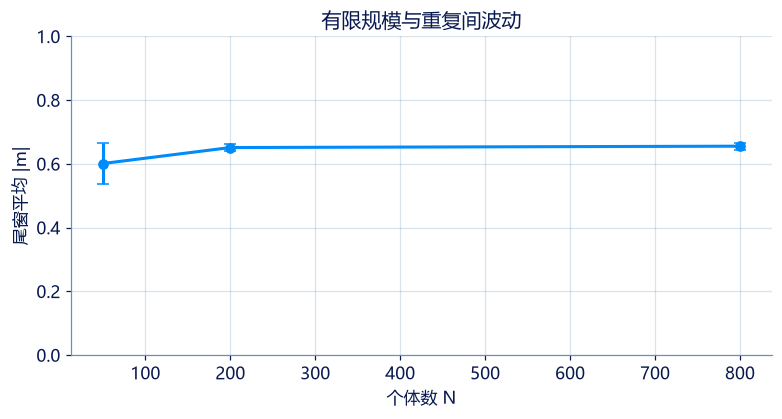

规模 / 12次重复均值 / 重复间标准差： [(50, [0.6009053497942387, 0.06464825420823259]), (200, [0.6510699588477367, 0.010207213158381393]), (800, [0.655354938271605, 0.0109909374863215])]


In [4]:
rng=np.random.default_rng(130101)
sizes=[50,200,800]; rows=[]
for n in sizes:
    paths=[]
    for repeat in range(12):
        draws=rng.random((120,n))
        paths.append(meanfield_path([1]*n,1.2,draws))
    rows.append(order_summary(paths,40))
fig,ax=plt.subplots(figsize=(7,3.7))
ax.errorbar(sizes,[row[0] for row in rows],yerr=[row[1] for row in rows],
            marker='o',capsize=4,color=BLUE)
ax.set(xlabel='个体数 N',ylabel='尾窗平均 |m|',ylim=(0,1),title='有限规模与重复间波动')
ax.grid(alpha=.25);plt.show()
print('规模 / 12次重复均值 / 重复间标准差：',list(zip(sizes,rows)))

## 结果解释

在相同初态和时长下，尾窗均值展示各规模的集体状态，误差条展示重复间的离散程度。靠近阈值时恢复较慢，可延长暂态后再次比较。

### 独立核对

从四个独立 ±1 变量直接核对 m 的条件期望和方差；也核对给定随机数的一次更新。

In [5]:
assert meanfield_step([1,-1,1,-1],0.,[.2,.4,.6,.8])==[1,1,-1,-1]
beta=1.2;m=.25;r=(1+math.tanh(beta*m))/2
np.testing.assert_allclose(4*r*(1-r)/50,(1-math.tanh(beta*m)**2)/50)
assert all(0<=row[0]<=1 and row[1]>=0 for row in rows)
print('条件矩、抽样和序参量范围核对通过。')

条件矩、抽样和序参量范围核对通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/13-01-%E7%9B%B8%E5%8F%98%E3%80%81%E4%B8%B4%E7%95%8C%E6%80%A7%E4%B8%8E%E6%9C%89%E9%99%90%E8%A7%84%E6%A8%A1/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：汇总有限系统的序参量

每条轨迹（trajectory）给出每一步的有符号磁化 m。按 burnin 删除前面的值；先对每条剩余轨迹求 |m| 的平均，再返回各次重复的平均与总体标准差（standard deviation）。

**函数与代码模板**

```python
def solve(
    paths: list[list[float]],
    burnin: int,
) -> list[float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `paths` | `list[list[float]]` | 按重复排列的磁化轨迹。 | 无量纲 |
| `burnin` | `int` | 舍弃每条轨迹开头的步数，至少保留一步。 | 步 |

**返回值**

直接返回 summary（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `summary` | `list[float]` | 依次为重复均值、重复间总体标准差。 | 无量纲 |

**计算规则**

分别先对每条轨迹的尾窗求 |m| 平均，再对这些重复结果求平均及除以重复数的标准差。

**约束与边界**

- 所有比较使用题定模型（model）和相同单位；仅输出（output）函数返回值，不依赖外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| paths | 按重复排列的磁化轨迹。 | [[0.0, 0.2, -0.4], [0.0, -0.4, -0.2]] | 无量纲 |
| burnin | 舍弃每条轨迹开头的步数，至少保留一步。 | 1 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
paths = [[0.0, 0.2, -0.4], [0.0, -0.4, -0.2]]
burnin = 1

result = solve(paths, burnin)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| summary | 依次为重复均值、重复间总体标准差。 | [0.30000000000000004, 0.0] | 无量纲 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.30000000000000004, 0.0]
```

**样例解释**

先在重复内部取尾窗绝对值，再在重复之间汇总；不把一次轨迹的波动当成重复间不确定性。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：汇总有限系统的序参量](http://127.0.0.1:8000/chapters/13-01-%E7%9B%B8%E5%8F%98%E3%80%81%E4%B8%B4%E7%95%8C%E6%80%A7%E4%B8%8E%E6%9C%89%E9%99%90%E8%A7%84%E6%A8%A1/practice/?question=p13-finite-order-summary)

### 第 2 题 · 单项选择题：为何区分有符号和绝对序参量

两次对称轨迹（trajectory）尾窗分别长期接近 m=+0.8 与 m=-0.8。下面哪项对两者汇总最准确？

- **A.** 有符号均值可能约为0，但平均 |m| 约为0.8。
- **B.** 有符号均值和平均 |m| 都必为0。
- **C.** 平均 |m| 大于1。
- **D.** 任何有限轨迹都能证明无限系统的相变。

[作答：为何区分有符号和绝对序参量](http://127.0.0.1:8000/chapters/13-01-%E7%9B%B8%E5%8F%98%E3%80%81%E4%B8%B4%E7%95%8C%E6%80%A7%E4%B8%8E%E6%9C%89%E9%99%90%E8%A7%84%E6%A8%A1/practice/?question=p13-signed-vs-absolute)

### 第 3 题 · 单项选择题：有限系统仍会波动

二值同步更新（synchronous update）中，每个个体条件独立（conditional independence）地以概率（probability） r 取 +1；在给定当前状态（state）下，下一步磁化的条件方差（variance）是多少？

- **A.** 4r(1-r)/N
- **B.** r(1-r)N
- **C.** 0，因为平均映射是确定的
- **D.** 4r(1-r)，与 N 无关

[作答：有限系统仍会波动](http://127.0.0.1:8000/chapters/13-01-%E7%9B%B8%E5%8F%98%E3%80%81%E4%B8%B4%E7%95%8C%E6%80%A7%E4%B8%8E%E6%9C%89%E9%99%90%E8%A7%84%E6%A8%A1/practice/?question=p13-finite-fluctuation)

### 第 4 题 · 单项选择题：一次突变代表什么

在 N=40 的一次模拟中，序参量（order parameter）在某参数（parameter）附近跳高。可以支持哪项结论？

- **A.** 这条有限轨迹（trajectory）在给定规则下出现较高序参量，需要重复和规模比较。
- **B.** 已经证明无限规模下发生相变。
- **C.** 阈值恰好等于该参数且无不确定性。
- **D.** 相变与确定性分岔（bifurcation）必是同一概念。

[作答：一次突变代表什么](http://127.0.0.1:8000/chapters/13-01-%E7%9B%B8%E5%8F%98%E3%80%81%E4%B8%B4%E7%95%8C%E6%80%A7%E4%B8%8E%E6%9C%89%E9%99%90%E8%A7%84%E6%A8%A1/practice/?question=p13-finite-evidence)

**进一步阅读**

[SFI Complexity Explorer 复杂系统课程](https://www.complexityexplorer.org/courses/185-introduction-to-complexity/faq)提供序参量与有限系统的延伸入口；本模型的具体同步更新规则在本节定义。